In [2]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot  as plt
import numpy as np
from utils import min_max_normalize

In [ ]:
df_res = pd.read_excel(r"..\..\outputs\df_ipp_v2f.xlsx")

# df_res_v2 = pd.read_excel(r"D:\repos\pessoal\redem-index\outputs\df_ipp_v2f.xlsx")
# df_res_v1 = pd.read_excel(r"D:\repos\pessoal\redem-index\outputs\df_res.xlsx")
# df_res = df_res_v1.merge(df_res_v2[['id', 'idLegislatura', 'tempo_atuacao_dias_cum_ln']])


# df_res['mesa_cum'] = df_res['mesa_1_cum'] + df_res['mesa_2_cum']
# df_res['mesa_cum_norm'] = min_max_normalize(df_res['mesa_1_cum']) 


# df_res['mandatos_cum'] = df_res['mand_dep_estadual_cum'] + df_res['mand_sen_cum'] + df_res['mand_dep_estadual_cum']
# df_res['mandatos_cum_norm'] = min_max_normalize(df_res['mandatos_cum'])

In [64]:
vars = [
    ("tempo_atuacao_dias_cum_ln", r"$TempoAtuacao$"),
    ("relatorias_ln_cum", r"$ln(Relatoria)$"),
    ("pos_lider_cum", r"$PosicaoLider$"),
    ("pos_comiss_pr_cum", r"$PresidenciaComissao$"),
    # ("mesa_1_cum", r"$Mesa2$"),
    # ("mesa_2_cum", r"$Mesa1$"),
    ("mesa_cum", r"$Mesa$"),
    # ("mand_ver_cum", r"$Mandato_{VER}$"),
    # ("mand_sen_cum", r"$Mandato_{SEN}$"),
    # ("mand_dep_estadual_cum", r"$Mandato_{DE}$"),
    ("mandatos_cum", r"$Mandatos$"),
    # ("idade_posse", r"$IdadePosse$"),
    # ("fid_municipais_cum", r"$FidelidadeMunicipais$"),
    ("fid_gerais_cum", r"$FidelidadeGerais$"),
]

In [65]:
cols = [v[0] for v in vars]

df_res = df_res.fillna(0)

df_res[cols].describe()

,tempo_atuacao_dias_cum_ln,relatorias_ln_cum,pos_lider_cum,pos_comiss_pr_cum,mesa_1_cum,mesa_2_cum,mand_ver_cum,mand_sen_cum,mand_dep_estadual_cum,idade_posse,fid_municipais_cum,fid_gerais_cum
count,6250.000000,6250.000000,6250.00000,6250.000000,6250.000000,6250.000000,6250.000000,6250.000000,6250.000000,6250.000000,6250.000000,6250.000000
mean,7.552827,2.130083,0.12624,0.254560,0.004640,0.021920,0.385280,0.025760,0.611520,44.990080,1.805440,1.297280
std,0.937759,1.731171,0.44964,0.600314,0.078864,0.184187,0.766794,0.192204,1.063421,9.802542,1.334058,1.340057
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.286876,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,38.000000,1.000000,0.000000
50%,7.286876,2.197225,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,1.000000,1.000000
75%,7.992690,3.548101,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,51.000000,2.000000,2.000000
max,9.416053,9.144414,5.00000,5.000000,2.000000,5.000000,6.000000,3.000000,7.000000,83.000000,9.000000,7.000000


In [66]:
# Definir o número de fatores como uma variável
n_factors = 3

final_loadings = []

for legislatura in df_res['idLegislatura'].unique():
    if legislatura < 52:
        continue

    df = df_res[df_res['idLegislatura'] == legislatura].loc[:, cols]

    for c in df.columns:
        df[f'{c}_norm'] = min_max_normalize(df[c])

    df = df[df.columns[len(cols):]]

    # Análise Fatorial
    fa = FactorAnalyzer(n_factors=n_factors, rotation=None)
    fa.fit(df)


    for i, c in enumerate(df.columns):
        max_loading_exp = np.max([np.exp(l) for l in fa.loadings_[i]])
        final_loadings.append(
            {"legis": legislatura, "column": c, "max_loading_exp": max_loading_exp}
        )

In [67]:
df_res_loadings = pd.DataFrame(final_loadings).sort_values(['column', 'legis'], ascending=False)

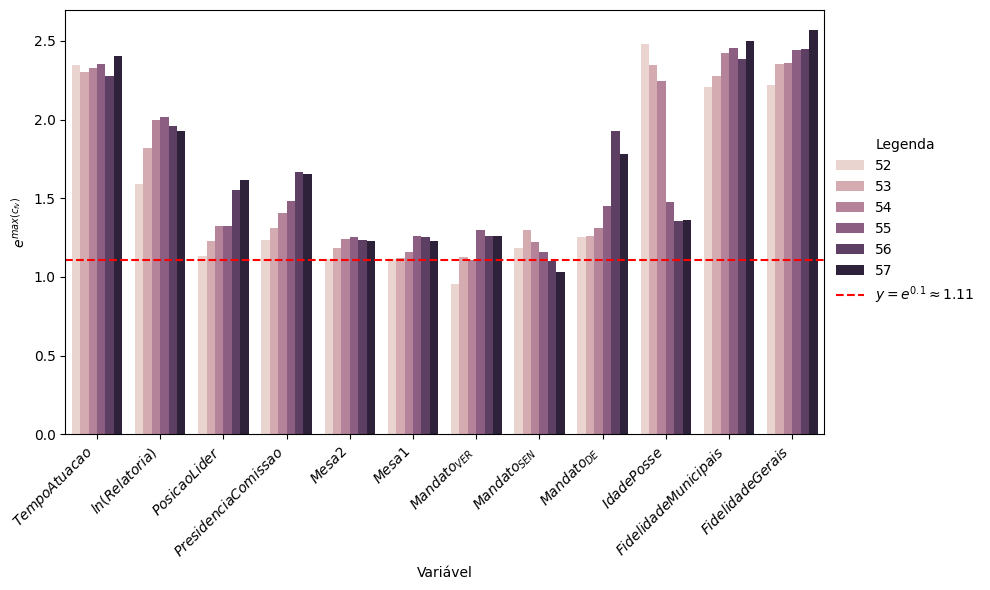

In [68]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df_res_loadings, x="column", y="max_loading_exp", hue="legis")

plt.axhline(
    y=np.exp(0.1), color="red", linestyle="--", label=r"$y=e^{0.1}\approx$" + f"{np.exp(0.1):.2f}"
)

# Add labels and title
plt.xlabel("Variável")
plt.ylabel(r"$e^{max(c_{fv})}$")
# plt.title('Barplot of Variables Colored by Legis')

plt.legend(title="Legenda", loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)


# Show the plot
custom_labels = [v[1] for v in vars]
plt.xticks(
    ticks=range(len(custom_labels)), labels=custom_labels, rotation=45, ha="right"
)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [62]:
pd.DataFrame(final_loadings).sort_values(
    ["column", "max_loading_exp"], ascending=False
).pivot_table(values="max_loading_exp", columns="legis", index="column").reset_index().to_excel('max_loading_exp_v1.xlsx')